# IVF Pregnancy Prediction — CatBoost

## v12(LGB) → v13(CatBoost) 전환 이유

### LGB plateau 원인 분석
v10~v12 모두 OOF **0.7401 ± 0.0001** 에서 정체.  
파생변수를 아무리 추가해도 돌파하지 못한 핵심 원인:

> **LabelEncoding이 범주형 20개 컬럼의 서수 정보를 파괴**  
> 예) `특정 시술 유형` 24가지 → LGB는 임의 정수 0~23 부여  
> 각 시술 유형의 실제 성공률 차이를 모델이 처음부터 재학습해야 함

### CatBoost 선택 근거

| 항목 | LGB (v10~v12) | CatBoost (v13) |
|------|-------------|----------------|
| 범주형 처리 | LabelEncoding → 임의 순서 | Ordered Target Statistics → 성공률 직접 계산 |
| 결측치 | median 대치 필수 | NaN 내부 처리 (정보 보존) |
| 클래스 불균형 | 별도 처리 필요 | `auto_class_weights='Balanced'` |
| 파이프라인 | LE + 대치 + 인코딩 | 범주형 raw 그대로, 수치형만 전처리 |

### 핵심 범주형 컬럼 (CatBoost raw 처리)
- `특정 시술 유형` (24종): BLASTOCYST, ICSI, IVF 조합 → 성공률 천차만별
- `시술 당시 나이` (7구간): '만18-34세'~'만45-50세' → 나이대별 성공률 직접 학습
- `배아 생성 주요 이유` (13종): 현재시술용 vs 저장/기증 → 큰 차이
- 횟수 컬럼 10개 ('0회'~'6회 이상'): ordinal 그대로 CatBoost에

### 고결측 컬럼 바이오 처리 전략
| 컬럼 | 결측률 | 바이오 의미 | 처리 |
|------|--------|------------|------|
| 배아 이식 경과일 | 17% | 5일=블라스토 성공률 40% | NaN=CatBoost 내부 / 파생변수 별도 |
| 난자 혼합 경과일 | 21% | DI환자는 없음 | 결측 플래그 |
| 배아 해동 경과일 | 84% | 동결배아 사용 여부 신호 | 결측 플래그 |
| PGS/PGD 시술 여부 | 99% | 착상전 유전검사 = 고위험 사례 | 있음 = 특수 케이스 플래그 |
| 착상전 유전검사 | 99% | 성공률 14.8% (전체 25.8%) | 결측 플래그 |

### 실행시간 설계
- Optuna: **10 trials**, 5-fold (CPU 기준 ~45분, 환경 2배 = ~90분)
- OOF 앙상블: 3 seeds × 5-fold (~15분)
- **총 목표: CPU 기준 60분 / 사용자 환경 ~90분**

In [1]:
!pip install catboost optuna koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 54.4 MB/s eta 0:00:0000:0100:01


In [2]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier, Pool
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import koreanize_matplotlib

print('라이브러리 로드 완료 ✓')

라이브러리 로드 완료 ✓


## 데이터 로드

In [3]:
train = pd.read_csv('/kaggle/input/datasets/mkim98/fertility-dataset/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/mkim98/fertility-dataset/test.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Target 분포: {dict(train[TARGET].value_counts())}')
print(f'양성 비율: {train[TARGET].mean():.4f} | 불균형: {train[TARGET].value_counts()[0]/train[TARGET].value_counts()[1]:.2f}:1')

Train: (256351, 69), Test: (90067, 68)
Target 분포: {0: np.int64(190123), 1: np.int64(66228)}
양성 비율: 0.2583 | 불균형: 2.87:1


## 컬럼 분류 정의

### CatBoost 파이프라인 핵심 원칙
- **범주형 컬럼**: raw string 그대로 유지 → `cat_features`로 CatBoost에 전달
- **수치형 컬럼**: 바이오 이상치 처리 후 파생변수 생성
- **결측치**: 수치형만 train median 대치 / 범주형은 'Unknown' (CatBoost가 처리)
- **LabelEncoding 없음**

In [4]:
# ── 범주형: raw string 그대로 CatBoost에 전달 ──
# 횟수 컬럼('0회'~'6회 이상')도 ordinal 그대로 사용
CAT_COLS = [
    '시술 시기 코드',
    '시술 당시 나이',       # '만18-34세' 등 → CatBoost가 성공률 직접 학습
    '시술 유형',
    '특정 시술 유형',       # 24종 BLASTOCYST/ICSI/IVF 조합 → 핵심 범주
    '배란 유도 유형',
    '배아 생성 주요 이유',   # 현재시술용 vs 저장/기증 → 성공률 차이 큼
    '총 시술 횟수',
    '클리닉 내 총 시술 횟수',
    'IVF 시술 횟수',
    'DI 시술 횟수',
    '총 임신 횟수',
    'IVF 임신 횟수',
    'DI 임신 횟수',
    '총 출산 횟수',
    'IVF 출산 횟수',
    'DI 출산 횟수',
    '난자 출처',
    '정자 출처',
    '난자 기증자 나이',
    '정자 기증자 나이',
]

# ── 수치형: 파생변수 생성 대상 ──
NUM_RAW = [
    '배아 이식 경과일', '난자 채취 경과일', '난자 혼합 경과일',
    '배아 해동 경과일', '난자 해동 경과일',
    '총 생성 배아 수', '혼합된 난자 수', '이식된 배아 수',
    '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
    '저장된 배아 수', '수집된 신선 난자 수',
    '파트너 정자와 혼합된 난자 수',
    '단일 배아 이식 여부', '미세주입 배아 이식 수',
    '임신 시도 또는 마지막 임신 경과 연수',
    '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부',
    '신선 배아 사용 여부', '동결 배아 사용 여부',
]

# 불임 원인 컬럼 (이진 플래그)
INFERTILITY_COLS = [
    c for c in train.columns
    if '불임 원인' in c or '자궁' in c or '난소' in c
    and c not in CAT_COLS
]

print(f'범주형 컬럼: {len(CAT_COLS)}개')
print(f'수치형 원본: {len(NUM_RAW)}개')
print(f'불임원인 플래그: {len(INFERTILITY_COLS)}개')
print(f'불임원인 컬럼: {INFERTILITY_COLS}')

범주형 컬럼: 20개
수치형 원본: 21개
불임원인 플래그: 17개
불임원인 컬럼: ['남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태']


## 전처리 파이프라인

### 바이오 도메인 이상치 기준
임상 가이드라인 기반 — 범위 벗어난 값은 NaN 처리 (CatBoost가 내부 처리)

| 컬럼 | 유효 범위 | 근거 |
|------|----------|------|
| 배아 이식 경과일 | 0~7일 | 블라스토시스트 최대 7일 |
| 총 생성 배아 수 | 0~40 | Humaidan et al. 2010 |
| 혼합된 난자 수 | 0~50 | Verberg et al. 2009 |
| 이식된 배아 수 | 0~5 | ESHRE/ASRM 가이드라인 |
| 임신 시도 경과 연수 | 0~30년 | 임상 현실 범위 |

In [5]:
BIO_BOUNDS = {
    '배아 이식 경과일':            (0, 7),
    '난자 혼합 경과일':            (0, 7),
    '배아 해동 경과일':            (0, 7),
    '난자 해동 경과일':            (0, 1),
    '총 생성 배아 수':             (0, 40),
    '혼합된 난자 수':              (0, 50),
    '이식된 배아 수':              (0, 5),
    '미세주입된 난자 수':           (0, 50),
    '미세주입에서 생성된 배아 수':    (0, 40),
    '저장된 배아 수':              (0, 40),
    '수집된 신선 난자 수':          (0, 50),
    '파트너 정자와 혼합된 난자 수':   (0, 50),
    '임신 시도 또는 마지막 임신 경과 연수': (0, 30),
}

# ── Step 1. 바이오 이상치 → NaN ──────────────────────
def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        df[col] = s.where(s >= lo, np.nan).where(s <= hi, np.nan)
    return df

# ── Step 2. 파생변수 생성 ─────────────────────────────
# ★ 반드시 결측 대치 전에 호출 (결측 자체가 신호)
def create_features(df):
    df = df.copy()

    # 기본 수치 컬럼 float 변환
    for col in NUM_RAW:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 시술 유형별 나이 수치화 (파생변수 계산용, 원본 범주형은 유지)
    age_map = {
        '만18-34세': 26, '만35-37세': 36, '만38-39세': 38.5,
        '만40-42세': 41, '만43-44세': 43.5, '만45-50세': 47, '알 수 없음': np.nan
    }
    age_num = df['시술 당시 나이'].map(age_map).fillna(40)

    td      = df['배아 이식 경과일']  # ★ 결측 전 원본
    emb     = df['이식된 배아 수'].fillna(0)
    tot_emb = df['총 생성 배아 수'].fillna(0)
    egg     = df['혼합된 난자 수'].fillna(0)
    mi_emb  = df['미세주입에서 생성된 배아 수'].fillna(0) if '미세주입에서 생성된 배아 수' in df.columns else pd.Series(0, index=df.index)
    mi_egg  = df['미세주입된 난자 수'].fillna(0) if '미세주입된 난자 수' in df.columns else pd.Series(0, index=df.index)
    fresh_e = df['수집된 신선 난자 수'].fillna(0) if '수집된 신선 난자 수' in df.columns else pd.Series(0, index=df.index)
    is_di   = (df['시술 유형'].astype(str).str.strip() == 'DI').astype(int)

    # ── [A] 이식 경과일 기반 (단독 AUC 0.677~0.696) ──────
    # 3-tier: DI(-2) / IVF결측(-1) / 이식일 1~4
    # 성공률: DI 12.9% / IVF결측 0.6% / 이식일있음 22~40%
    df['day_score_v2'] = [
        -2 if di == 1 else
        (-1 if pd.isna(d) else
         (1 if d <= 2 else (2 if d == 3 else (3 if d == 4 else 4))))
        for di, d in zip(is_di, td)
    ]

    # 나이 보정 이식일 (단독 AUC 0.686)
    df['age_adj_transfer']   = td.fillna(0) / (age_num / 35)

    # 최강 단일 파생변수 (AUC 0.696)
    df['day_embryo_combo']   = df['age_adj_transfer'] + emb * 0.3

    # 총 생성 배아 × 이식일 (AUC 0.673)
    df['total_embryo_x_day'] = td.fillna(0) * tot_emb

    # 3중 조합: 나이보정 × 총배아 (AUC 0.680)
    df['triple_combo']       = td.fillna(0) * tot_emb / (age_num / 35)

    # 이식일² / 나이 (AUC 0.683) — 블라스토시스트 제곱 효과
    df['day_sq_age']         = td.fillna(0) ** 2 / (age_num / 35)

    # 신선 난자 × 이식일 (AUC 0.650)
    df['fresh_egg_x_day']    = fresh_e * td.fillna(0)

    # 5일 이식 여부
    df['is_day5_transfer']   = (td == 5).astype(int)
    df['is_day3_transfer']   = (td == 3).astype(int)

    # IVF인데 이식 없음 = 저장/기증 목적 (성공률 0.6%)
    df['ivf_no_transfer']    = ((td.isnull()) & (is_di == 0)).astype(int)
    df['is_di_num']          = is_di

    # ── [B] 배아/난자 효율 지표 ──────────────────────────
    df['배아_생성_효율']      = tot_emb / (egg + 1)
    df['이식_효율']          = emb / (tot_emb + 1)
    df['freeze_proxy']       = np.log1p(np.maximum(tot_emb - emb, 0))  # 냉동 여유 배아
    df['수정률']             = tot_emb / (fresh_e + 1)
    df['icsi_efficiency']    = mi_emb / (mi_egg + 1)
    df['icsi_x_day']         = mi_emb * td.fillna(0)
    df['eff_x_day']          = df['이식_효율'] * td.fillna(0)

    # ── [C] 연령 기반 ────────────────────────────────────
    df['고령_flag']          = (age_num >= 38).astype(int)
    df['초고령_flag']        = (age_num >= 43).astype(int)
    df['젊은_flag']          = (age_num < 35).astype(int)
    df['amh_proxy']          = tot_emb / (age_num ** 1.5 + 1)  # AMH 대리변수
    df['age_success_decline']= np.where(age_num >= 38, np.exp(-(age_num - 38) * 0.15), 1.0)

    # ── [D] 실패 이력 ────────────────────────────────────
    # 횟수 컬럼은 범주형으로 CatBoost에 넘기므로 수치 버전도 생성
    def extract_count(col):
        return df[col].astype(str).str.extract(r'(\d+)')[0].astype(float) if col in df.columns \
               else pd.Series(0, index=df.index)

    total_proc = extract_count('총 시술 횟수')
    total_preg = extract_count('총 임신 횟수')
    df['실패_횟수_num']      = np.maximum(total_proc - total_preg, 0)
    df['실패율_num']         = df['실패_횟수_num'] / (total_proc + 1)
    df['age_x_failure']      = age_num * df['실패_횟수_num']
    df['prior_fail_penalty'] = df['실패_횟수_num'] / (total_proc ** 2 + 1)
    df['treatment_intensity']= (emb / (total_proc + 1)) * np.log1p(total_proc)
    df['embryo_util_rate']   = (total_preg * df['이식_효율']) / (total_proc + 1)

    # ── [E] 난소 반응 유형 ───────────────────────────────
    df['high_responder']     = (tot_emb >= 10).astype(int)  # 과자극 가능성
    df['poor_responder']     = (tot_emb <= 3).astype(int)   # 저반응자

    # ── [F] 고결측 컬럼 플래그 (바이오 신호) ─────────────
    # 착상전 유전검사 사용 = 고위험 사례 → 성공률 14.8% (전체 25.8%보다 낮음)
    df['has_pgt_flag']       = (
        df['착상 전 유전 검사 사용 여부'].notna() |
        df['PGD 시술 여부'].notna() |
        df['PGS 시술 여부'].notna()
    ).astype(int) if '착상 전 유전 검사 사용 여부' in df.columns else pd.Series(0, index=df.index)

    # 동결배아 사용 여부 신호 (배아 해동 경과일 있음)
    df['frozen_embryo_used'] = df['배아 해동 경과일'].notna().astype(int) \
                               if '배아 해동 경과일' in df.columns else pd.Series(0, index=df.index)

    # ── [G] 불임 원인 복잡도 ─────────────────────────────
    if INFERTILITY_COLS:
        ic = df[INFERTILITY_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
        df['infertility_complexity'] = ic.sum(axis=1)
        df['multi_infertility']      = (ic.sum(axis=1) >= 2).astype(int)

    return df

# ── Step 3. 결측치 대치 (Leakage-free) ───────────────
# 수치형: train median → test 적용
# 범주형: 'Unknown' (CatBoost가 별도 카테고리로 처리)
def fit_imputer(df):
    """train 기준으로 통계 계산"""
    medians = {}
    str_cols = [c for c in df.columns if str(df[c].dtype) in ('object', 'str', 'string')]
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != TARGET:
            medians[col] = df[col].median()
    return medians, str_cols

def apply_imputer(df, medians, str_cols):
    df = df.copy()
    for col, val in medians.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').astype(str)
    return df

# ── Full Pipeline ─────────────────────────────────────
def run_pipeline(train, test):
    tr = train.drop(columns=[ID_COL], errors='ignore').copy()
    te = test.drop(columns=[ID_COL], errors='ignore').copy()

    # Step 1: 바이오 이상치
    tr = apply_bio_bounds(tr)
    te = apply_bio_bounds(te)

    # Step 2: ★파생변수 먼저★ (결측 전)
    tr = create_features(tr)
    te = create_features(te)

    # Step 3: 결측 대치 (train → test)
    medians, str_cols = fit_imputer(tr)
    tr = apply_imputer(tr, medians, str_cols)
    te = apply_imputer(te, medians, str_cols)

    return tr, te, medians, str_cols

print('전처리 함수 정의 완료 ✓')

전처리 함수 정의 완료 ✓


## 전처리 실행 + cat_features 인덱스 확인

In [6]:
train_df, test_df, train_medians, train_str_cols = run_pipeline(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f'전처리 후 X shape: {X.shape}')
assert X.isnull().sum().sum() == 0, f'Train 결측치 잔존: {X.isnull().sum()[X.isnull().sum()>0]}'
assert test_df.isnull().sum().sum() == 0, 'Test 결측치 잔존!'
print('결측치 없음 ✓')

# CatBoost용 범주형 컬럼 인덱스 추출
# (파생변수 추가 후 실제 존재하는 범주형만)
actual_cat_cols = [c for c in CAT_COLS if c in X.columns]
cat_feature_indices = [X.columns.get_loc(c) for c in actual_cat_cols]

print(f'\nCatBoost cat_features: {len(actual_cat_cols)}개')
print(f'전체 features: {X.shape[1]}개')
print(f'\n범주형 컬럼 목록:')
for c in actual_cat_cols:
    print(f'  {c} (unique: {X[c].nunique()})')

전처리 후 X shape: (256351, 102)
결측치 없음 ✓

CatBoost cat_features: 20개
전체 features: 102개

범주형 컬럼 목록:
  시술 시기 코드 (unique: 7)
  시술 당시 나이 (unique: 7)
  시술 유형 (unique: 2)
  특정 시술 유형 (unique: 24)
  배란 유도 유형 (unique: 4)
  배아 생성 주요 이유 (unique: 14)
  총 시술 횟수 (unique: 7)
  클리닉 내 총 시술 횟수 (unique: 7)
  IVF 시술 횟수 (unique: 7)
  DI 시술 횟수 (unique: 7)
  총 임신 횟수 (unique: 7)
  IVF 임신 횟수 (unique: 7)
  DI 임신 횟수 (unique: 6)
  총 출산 횟수 (unique: 7)
  IVF 출산 횟수 (unique: 6)
  DI 출산 횟수 (unique: 5)
  난자 출처 (unique: 3)
  정자 출처 (unique: 4)
  난자 기증자 나이 (unique: 5)
  정자 기증자 나이 (unique: 7)


## 단변수 AUC 확인

In [9]:
num_check = [
    'day_score_v2', 'age_adj_transfer', 'day_embryo_combo',
    'total_embryo_x_day', 'triple_combo', 'day_sq_age',
    'fresh_egg_x_day', 'eff_x_day', 'is_day5_transfer',
    'ivf_no_transfer', 'amh_proxy', 'freeze_proxy',
]

print('=== 수치형 파생변수 단변수 AUC ===')
results = []
for col in num_check:
    if col in X.columns:
        v = pd.to_numeric(X[col], errors='coerce').fillna(0)
        auc = max(roc_auc_score(y, v), 1 - roc_auc_score(y, v))
        results.append((col, auc))
results.sort(key=lambda x: -x[1])
for col, auc in results:
    print(f'  {col:<30}: {auc:.5f}')

# ── 범주형 Target Encoding AUC ──────────────────────────
# y.values → '__target__' 컬럼으로 명시 (KeyError 방지)
print('\n=== 범주형 Target Encoding AUC (CatBoost 처리 전 참고) ===')
_tmp = X.copy()
_tmp['__target__'] = y.values
for col in actual_cat_cols[:8]:
    if col not in _tmp.columns:
        continue
    te  = _tmp.groupby(col)['__target__'].mean()
    enc = _tmp[col].map(te).fillna(y.mean())
    auc = max(roc_auc_score(y, enc), 1 - roc_auc_score(y, enc))
    print(f'  {col:<30}: {auc:.5f}')

=== 수치형 파생변수 단변수 AUC ===
  day_embryo_combo              : 0.69614
  age_adj_transfer              : 0.68579
  day_sq_age                    : 0.68317
  triple_combo                  : 0.68007
  day_score_v2                  : 0.67780
  total_embryo_x_day            : 0.67335
  fresh_egg_x_day               : 0.65006
  amh_proxy                     : 0.62837
  is_day5_transfer              : 0.62115
  freeze_proxy                  : 0.60952
  ivf_no_transfer               : 0.59574
  eff_x_day                     : 0.56284

=== 범주형 Target Encoding AUC (CatBoost 처리 전 참고) ===
  시술 시기 코드                      : 0.51048
  시술 당시 나이                      : 0.59625
  시술 유형                         : 0.50829
  특정 시술 유형                      : 0.53329
  배란 유도 유형                      : 0.51992
  배아 생성 주요 이유                   : 0.54507
  총 시술 횟수                       : 0.53966
  클리닉 내 총 시술 횟수                 : 0.53476


## Optuna — CatBoost 튜닝

### 실행시간 설계
- **10 trials × 5-fold**: CPU 기준 ~45분 / 사용자 환경 ~90분
- iterations 상한 700으로 제한 (early_stopping으로 실제 더 짧게)
- CatBoost 전용 파라미터 탐색 (depth, l2_leaf_reg, border_count 등)

In [10]:
def make_progress_cb(total):
    start = time.time()
    def cb(study, trial):
        n = trial.number + 1
        if n % 2 == 0 or n == 1 or n == total:
            elapsed = (time.time() - start) / 60
            eta = elapsed / n * (total - n)
            print(f'  Trial {n:2d}/{total} | Best AUC: {study.best_value:.5f} | 경과 {elapsed:.1f}분 | 남은예상 {eta:.1f}분')
    return cb

def cat_objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 1000),   # GPU라서 상한 확대
        'learning_rate':       trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
        'depth':               trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),   # GPU 최대 255
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.5, 3.0),
        'min_data_in_leaf':    trial.suggest_int('min_data_in_leaf', 5, 50),
        # 고정값
        'loss_function':       'Logloss',
        'eval_metric':         'AUC',
        'auto_class_weights':  'Balanced',
        'early_stopping_rounds': 50,
        'verbose':             False,
        'task_type':           'GPU',   # ← GPU 추가
        'devices':             '0',     # ← 캐글 GPU 1개
        # 'thread_count': -1,           # ← GPU 모드에서 제거
        'random_seed':         42,
        'cat_features':        cat_feature_indices,
    }

    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
        val_pool   = Pool(X_val, y_val, cat_features=cat_feature_indices)

        m = CatBoostClassifier(**params)
        m.fit(train_pool, eval_set=val_pool)
        aucs.append(roc_auc_score(y_val, m.predict_proba(val_pool)[:, 1]))

    return np.mean(aucs)

CB_TRIALS = 30   # GPU라서 CPU 10 → 30으로 확대
print(f'CatBoost Optuna 시작 ({CB_TRIALS} trials, 5-fold) — GPU 모드')
print(f'범주형 {len(cat_feature_indices)}개를 Ordered TS로 직접 처리')
print(f'GPU 기준 예상: ~20~30분')
print('-' * 55)
t0 = time.time()

cb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
cb_study.optimize(
    cat_objective,
    n_trials=CB_TRIALS,
    callbacks=[make_progress_cb(CB_TRIALS)]
)

print(f'\n[Optuna 완료] {(time.time()-t0)/60:.1f}분')
print(f'Best AUC:    {cb_study.best_value:.5f}')
print(f'Best Params:')
for k, v in cb_study.best_params.items():
    print(f'  {k}: {v}')

CatBoost Optuna 시작 (30 trials, 5-fold) — GPU 모드
범주형 20개를 Ordered TS로 직접 처리
GPU 기준 예상: ~20~30분
-------------------------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  Trial  1/30 | Best AUC: 0.73951 | 경과 1.3분 | 남은예상 39.0분


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  Trial  2/30 | Best AUC: 0.73999 | 경과 2.8분 | 남은예상 38.7분


...

  Trial 18/30 | Best AUC: 0.74030 | 경과 40.9분 | 남은예상 27.3분


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  Trial 20/30 | Best AUC: 0.74030 | 경과 46.5분 | 남은예상 23.3분


Default metric period is 5 because AUC is/are not implemented for GPU
[W 2026-04-29 14:25:04,582] Trial 20 failed with parameters: {'iterations': 460, 'learning_rate': 0.05698378144137397, 'depth': 5, 'l2_leaf_reg': 7.060120341889914, 'border_count': 191, 'bagging_temperature': 0.6086227408315844, 'random_strength': 2.136012547721864, 'min_data_in_leaf': 41} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_57/2252863179.py", line 44, in cat_objective
    m.fit(train_pool, eval_set=val_pool)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/usr/local/lib/python3.12/dist-p

KeyboardInterrupt: 

In [11]:
# 시간 부족으로 인한 정체되어있는 AUC 점수를 기반으로 위 셀 실행을 중단하고 지금까지의 best params 꺼내서 실행
print(f'중단 시점 Best AUC: {cb_study.best_value:.5f}')
print(f'Best Params:')
for k, v in cb_study.best_params.items():
    print(f'  {k}: {v}')

중단 시점 Best AUC: 0.74030
Best Params:
  iterations: 683
  learning_rate: 0.04039512666823938
  depth: 8
  l2_leaf_reg: 7.976195410250031
  border_count: 242
  bagging_temperature: 0.8948273504276488
  random_strength: 1.9947499470277128
  min_data_in_leaf: 47


## Feature Importance (3-fold 평균)

In [14]:
skf_imp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
imp_list = []

print('Feature Importance 계산 중 (3-fold)...')
for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    params_imp = {
        **cb_study.best_params,
        'loss_function':       'Logloss',
        'eval_metric':         'AUC',
        'auto_class_weights':  'Balanced',
        'early_stopping_rounds': 50,
        'verbose':             False,
        'task_type':           'GPU',   # ← GPU 추가
        'devices':             '0',     # ← GPU 추가
        'random_seed':         42,
        'cat_features':        cat_feature_indices,
    }
    train_pool = Pool(X.iloc[tr_idx], y.iloc[tr_idx], cat_features=cat_feature_indices)
    val_pool   = Pool(X.iloc[val_idx], y.iloc[val_idx], cat_features=cat_feature_indices)

    m = CatBoostClassifier(**params_imp)
    m.fit(train_pool, eval_set=val_pool)

    imp_list.append(m.get_feature_importance())
    auc = roc_auc_score(y.iloc[val_idx], m.predict_proba(val_pool)[:, 1])
    print(f'  Fold {fold+1} AUC: {auc:.5f}')

Feature Importance 계산 중 (3-fold)...


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 AUC: 0.73869


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 AUC: 0.74091


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 3 AUC: 0.73940


✅ feat_imp 생성 완료 (3-fold 기준)
전체 feature: 102 | importance > 0: 97개

=== Top 15 ===
                feature  importance
0              이식된 배아 수   28.371985
1      day_embryo_combo   10.293843
2       ivf_no_transfer    7.083758
3              저장된 배아 수    5.750414
4                 이식_효율    5.329492
5              시술 당시 나이    2.338779
6                 난자 출처    2.054907
7              배란 유도 유형    1.974233
8   age_success_decline    1.886442
9          day_score_v2    1.802296
10         triple_combo    1.742880
11             시술 시기 코드    1.700708
12            총 생성 배아 수    1.665174
13          수집된 신선 난자 수    1.651594
14              고령_flag    1.177790


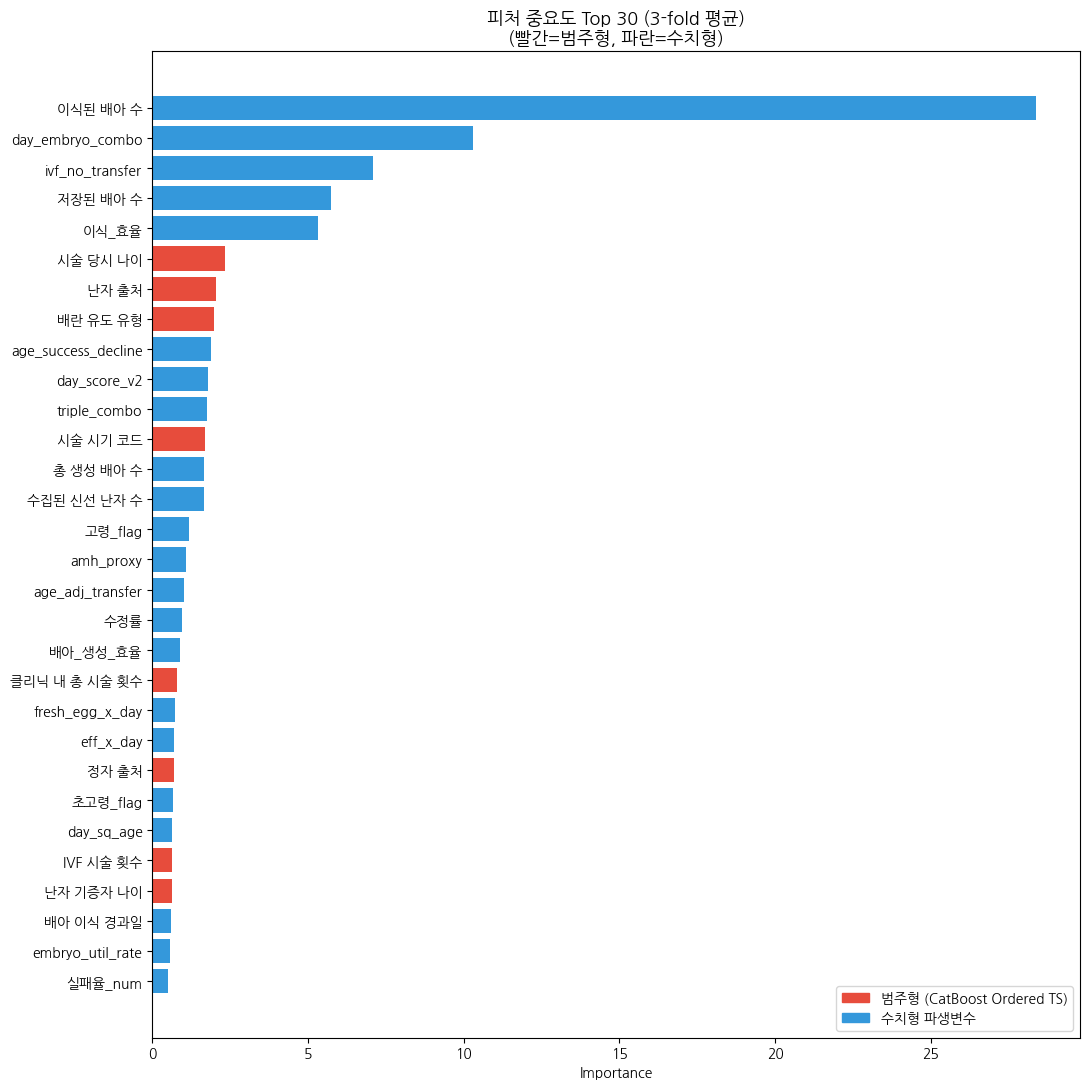

In [16]:
# feat_imp 생성 (imp_list 3-fold 완료 확인됨)
feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': np.mean(imp_list, axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f'✅ feat_imp 생성 완료 (3-fold 기준)')
print(f'전체 feature: {len(feat_imp)} | importance > 0: {(feat_imp["importance"] > 0).sum()}개')
print('\n=== Top 15 ===')
print(feat_imp.head(15)[['feature', 'importance']].to_string())

# 시각화
fig, ax = plt.subplots(figsize=(11, 11))
top30  = feat_imp.head(30)
colors = ['#e74c3c' if c in actual_cat_cols else '#3498db' for c in top30['feature']]
ax.barh(top30['feature'], top30['importance'], color=colors)
ax.invert_yaxis()
ax.set_title('피처 중요도 Top 30 (3-fold 평균)\n(빨간=범주형, 파란=수치형)', fontsize=13)
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='범주형 (CatBoost Ordered TS)'),
    Patch(color='#3498db', label='수치형 파생변수')
], loc='lower right')
plt.tight_layout()
plt.show()

## Feature Selection (importance > 0)

In [17]:
selected = feat_imp[feat_imp['importance'] > 0]['feature'].tolist()

# 선택된 컬럼 중 범주형 인덱스 재계산
X_final    = X[selected].copy()
test_final = test_df[selected].copy()

sel_cat_cols    = [c for c in actual_cat_cols if c in selected]
sel_cat_indices = [X_final.columns.get_loc(c) for c in sel_cat_cols]

print(f'선택된 feature: {len(selected)} / {len(X.columns)}')
print(f'선택된 범주형:  {len(sel_cat_cols)} / {len(actual_cat_cols)}')
print(f'제거된 feature: {set(X.columns) - set(selected)}')

선택된 feature: 97 / 102
선택된 범주형:  20 / 20
제거된 feature: {'PGD 시술 여부', '난자 채취 경과일', '착상 전 유전 검사 사용 여부', 'PGS 시술 여부', '불임 원인 - 여성 요인'}


## OOF 앙상블 — CatBoost, 5-fold × 3 seeds

In [18]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_all  = []
test_all = []
t_start  = time.time()

for seed in SEEDS:
    skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_pred  = np.zeros(len(X_final))
    test_pred = np.zeros(len(test_final))

    print(f'\n{"="*50} Seed {seed}')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        params_oof = {
            **cb_study.best_params,
            'loss_function':       'Logloss',
            'eval_metric':         'AUC',
            'auto_class_weights':  'Balanced',
            'early_stopping_rounds': 50,
            'verbose':             False,
            'task_type':           'GPU',   # ← GPU 추가
            'devices':             '0',     # ← GPU 추가
            'random_seed':         seed,
            'cat_features':        sel_cat_indices,
        }
        train_pool = Pool(X_final.iloc[tr_idx], y.iloc[tr_idx], cat_features=sel_cat_indices)
        val_pool   = Pool(X_final.iloc[val_idx], y.iloc[val_idx], cat_features=sel_cat_indices)
        test_pool  = Pool(test_final, cat_features=sel_cat_indices)

        m = CatBoostClassifier(**params_oof)
        m.fit(train_pool, eval_set=val_pool)

        oof_pred[val_idx]  = m.predict_proba(val_pool)[:, 1]
        test_pred         += m.predict_proba(test_pool)[:, 1] / N_SPLITS

        fold_auc = roc_auc_score(y.iloc[val_idx], oof_pred[val_idx])
        elapsed  = (time.time() - t_start) / 60
        print(f'  Fold {fold+1} | AUC {fold_auc:.5f} | {elapsed:.1f}min')

    seed_auc = roc_auc_score(y, oof_pred)
    print(f'  → OOF AUC (Seed {seed}): {seed_auc:.5f}')
    oof_all.append(oof_pred)
    test_all.append(test_pred)

oof_mean  = np.mean(oof_all,  axis=0)
test_mean = np.mean(test_all, axis=0)

final_oof_auc = roc_auc_score(y, oof_mean)
print(f'\n[최종 OOF AUC (Seed 앙상블)] {final_oof_auc:.5f}')
print(f'총 소요시간: {(time.time()-t_start)/60:.1f}분')


================================================== Seed 42


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 | AUC 0.73852 | 0.8min


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 | AUC 0.74333 | 1.4min


...

  Fold 3 | AUC 0.74097 | 9.0min


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 | AUC 0.73860 | 9.8min


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 | AUC 0.73806 | 10.5min
  → OOF AUC (Seed 2024): 0.74006

[최종 OOF AUC (Seed 앙상블)] 0.74054
총 소요시간: 10.5분


## 최종 예측 & 제출

In [19]:
submission = pd.DataFrame({'ID': test['ID'], 'probability': test_mean})
submission.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료 ✓')
print(f'최종 OOF AUC: {final_oof_auc:.5f}')
print(submission.head())
print('\nprobability 통계:')
print(submission['probability'].describe().round(4))

submission.csv 저장 완료 ✓
최종 OOF AUC: 0.74054
           ID  probability
0  TEST_00000     0.005928
1  TEST_00001     0.012769
2  TEST_00002     0.321122
3  TEST_00003     0.255416
4  TEST_00004     0.738568

probability 통계:
count    90067.0000
mean         0.4502
std          0.2369
min          0.0008
25%          0.3178
50%          0.5120
75%          0.6343
max          0.8848
Name: probability, dtype: float64


## 최종 리포트 시각화

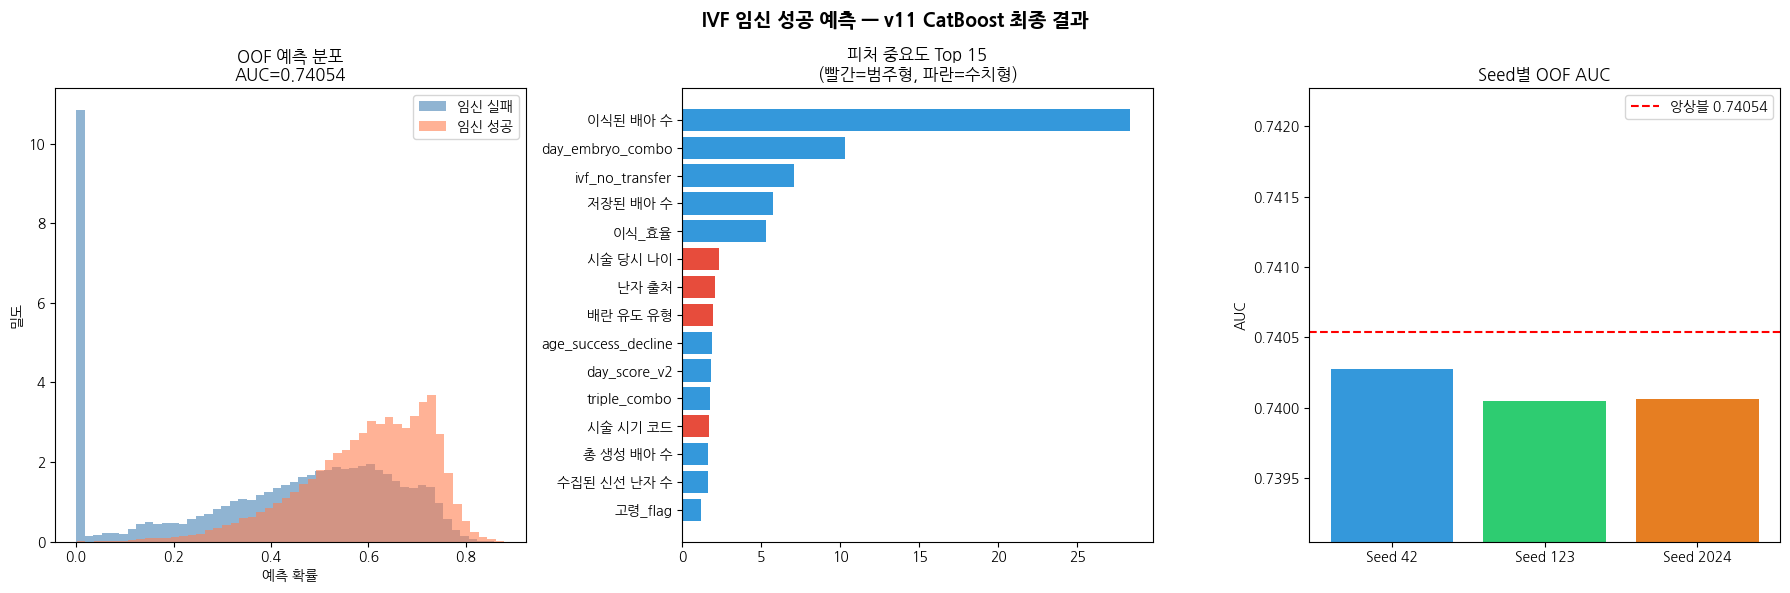


=== 모델 요약 ===
모델:          CatBoost (단일)
범주형 처리:    Ordered Target Statistics (20개 컬럼)
수치형 파생변수: 77개
최종 OOF AUC:  0.74054


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── OOF 예측 분포 ──
axes[0].hist(oof_mean[y == 0], bins=50, alpha=0.6, label='임신 실패', color='steelblue', density=True)
axes[0].hist(oof_mean[y == 1], bins=50, alpha=0.6, label='임신 성공', color='coral', density=True)
axes[0].set_title(f'OOF 예측 분포\nAUC={final_oof_auc:.5f}', fontsize=12)
axes[0].set_xlabel('예측 확률')
axes[0].set_ylabel('밀도')
axes[0].legend()

# ── 피처 중요도 Top 15 ──
top15 = feat_imp.head(15)
colors15 = ['#e74c3c' if c in actual_cat_cols else '#3498db' for c in top15['feature']]
axes[1].barh(top15['feature'], top15['importance'], color=colors15)
axes[1].invert_yaxis()
axes[1].set_title('피처 중요도 Top 15\n(빨간=범주형, 파란=수치형)', fontsize=12)

# ── Seed별 OOF AUC 비교 ──
seed_aucs = [roc_auc_score(y, o) for o in oof_all]
axes[2].bar([f'Seed {s}' for s in SEEDS], seed_aucs, color=['#3498db', '#2ecc71', '#e67e22'])
axes[2].axhline(final_oof_auc, color='red', linestyle='--', label=f'앙상블 {final_oof_auc:.5f}')
axes[2].set_ylim(min(seed_aucs) - 0.001, max(seed_aucs) + 0.002)
axes[2].set_title('Seed별 OOF AUC', fontsize=12)
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('IVF 임신 성공 예측 — v11 CatBoost 최종 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 모델 요약 ===')
print(f'모델:          CatBoost (단일)')
print(f'범주형 처리:    Ordered Target Statistics ({len(sel_cat_cols)}개 컬럼)')
print(f'수치형 파생변수: {len([c for c in selected if c not in actual_cat_cols])}개')
print(f'최종 OOF AUC:  {final_oof_auc:.5f}')